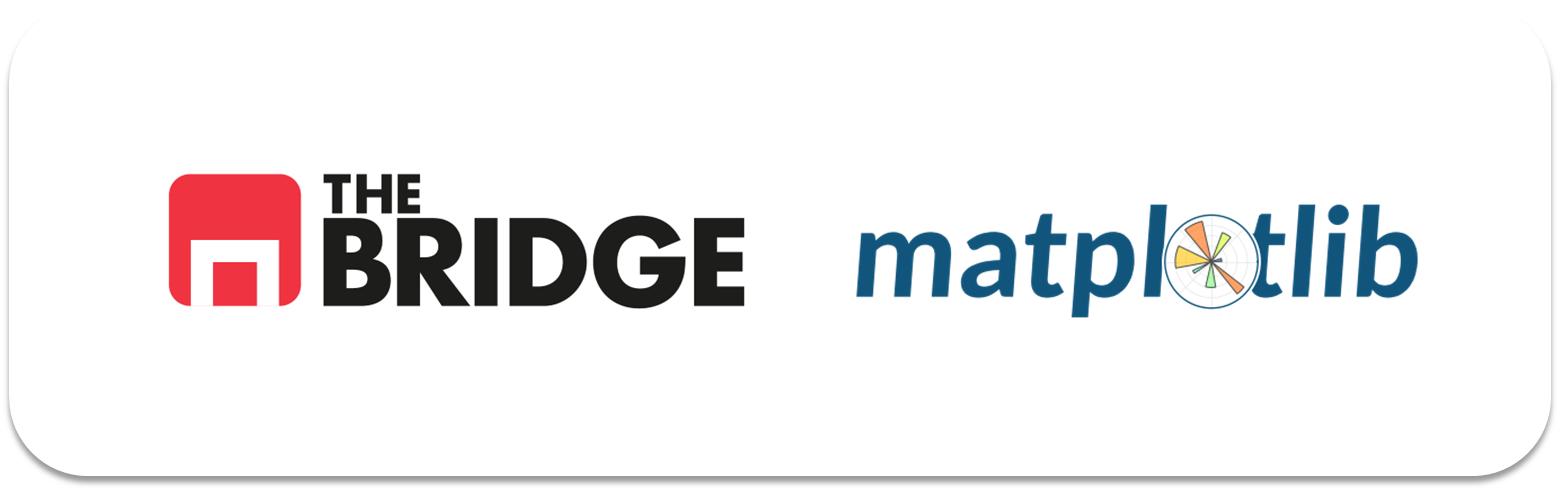

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("classic")

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df=pd.read_csv("./data/california_cities.csv")
display(df)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:

1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  



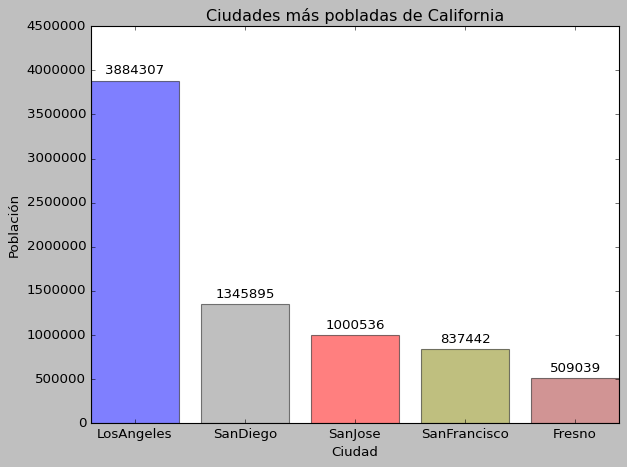

In [3]:
top5 = df.nlargest(5, "population_total")[["city", "population_total"]].reset_index(drop=True)
colores = ["blue", "gray", "red", "olive", "brown"]

fig1, ax1 = plt.subplots()
bars = ax1.bar(top5["city"], top5["population_total"], color=colores, alpha=0.5)
ax1.bar_label(bars,fmt="%d", label_type="edge", padding=3)
ax1.set_title("Ciudades más pobladas de California")
ax1.set_xlabel("Ciudad")
ax1.set_ylim(0,4500000)
ax1.set_ylabel("Población")
plt.tight_layout()
plt.show()

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")


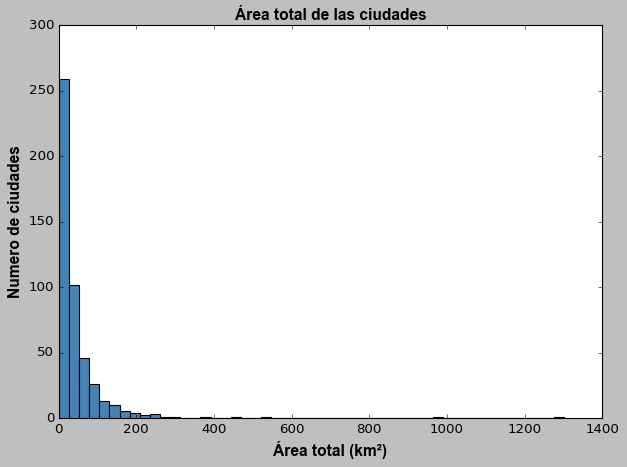

In [4]:
fig2, ax2 = plt.subplots()
ax2.hist(df["area_total_km2"], bins=50, color="steelblue")
ax2.set_title("Área total de las ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax2.set_xlabel("Área total (km²)", fontname="Arial", fontsize=14, fontweight="bold")
ax2.set_ylabel("Numero de ciudades", fontname="Arial", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

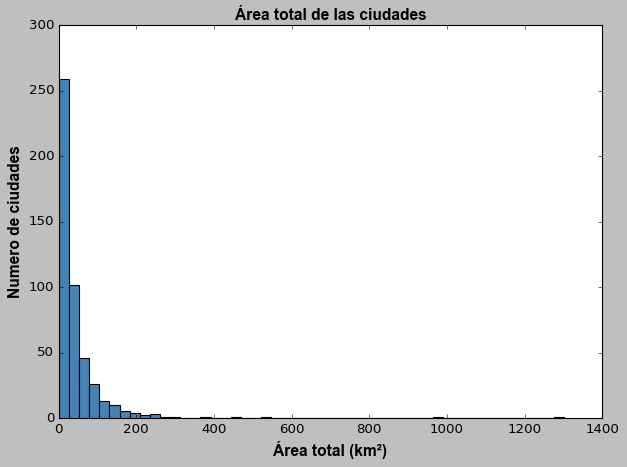

In [5]:
fig2, ax2 = plt.subplots()
ax2.hist(df["area_total_km2"], bins=50, color="steelblue")
kwargs={
    "fontname":"Arial", 
    "fontsize":14, 
    "fontweight":"bold"
}
ax2.set_title("Área total de las ciudades", **kwargs)
ax2.set_xlabel("Área total (km²)", **kwargs)
ax2.set_ylabel("Numero de ciudades", **kwargs)
plt.tight_layout()
plt.show()

3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.


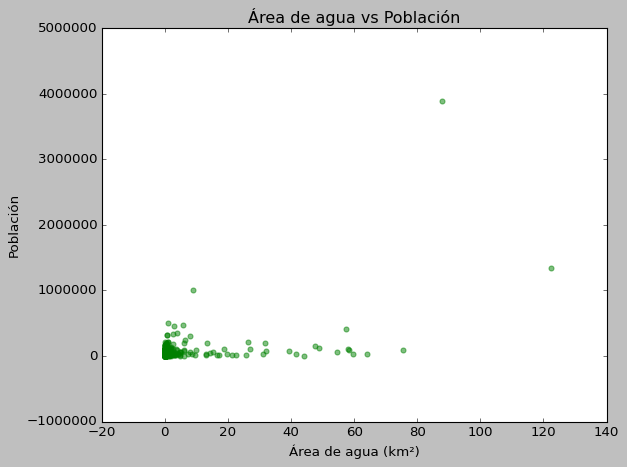

In [6]:
fig3, ax3 = plt.subplots()
ax3.scatter(df["area_water_km2"], df["population_total"], alpha=0.5, color="green")
ax3.set_title("Área de agua vs Población")
ax3.set_xlabel("Área de agua (km²)")
ax3.set_ylabel("Población")
plt.tight_layout()
plt.show()

4. El boxplot de la altura de las ciudades.

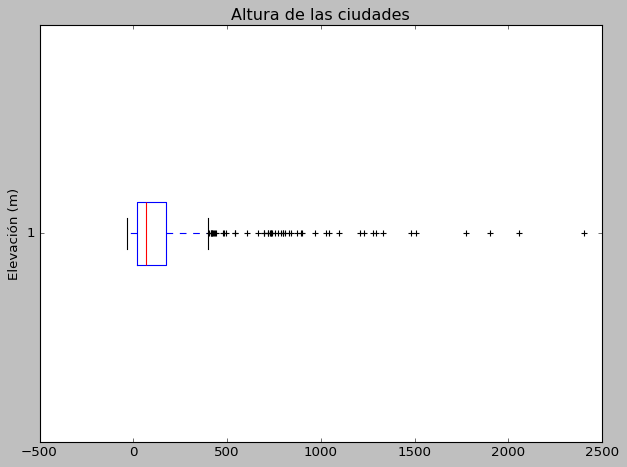

In [7]:
fig4, ax4 = plt.subplots()
ax4.boxplot(df["elevation_m"].dropna(), whis=1.5, vert=False)
ax4.set_title("Altura de las ciudades")
ax4.set_ylabel("Elevación (m)")
plt.tight_layout()
plt.show()

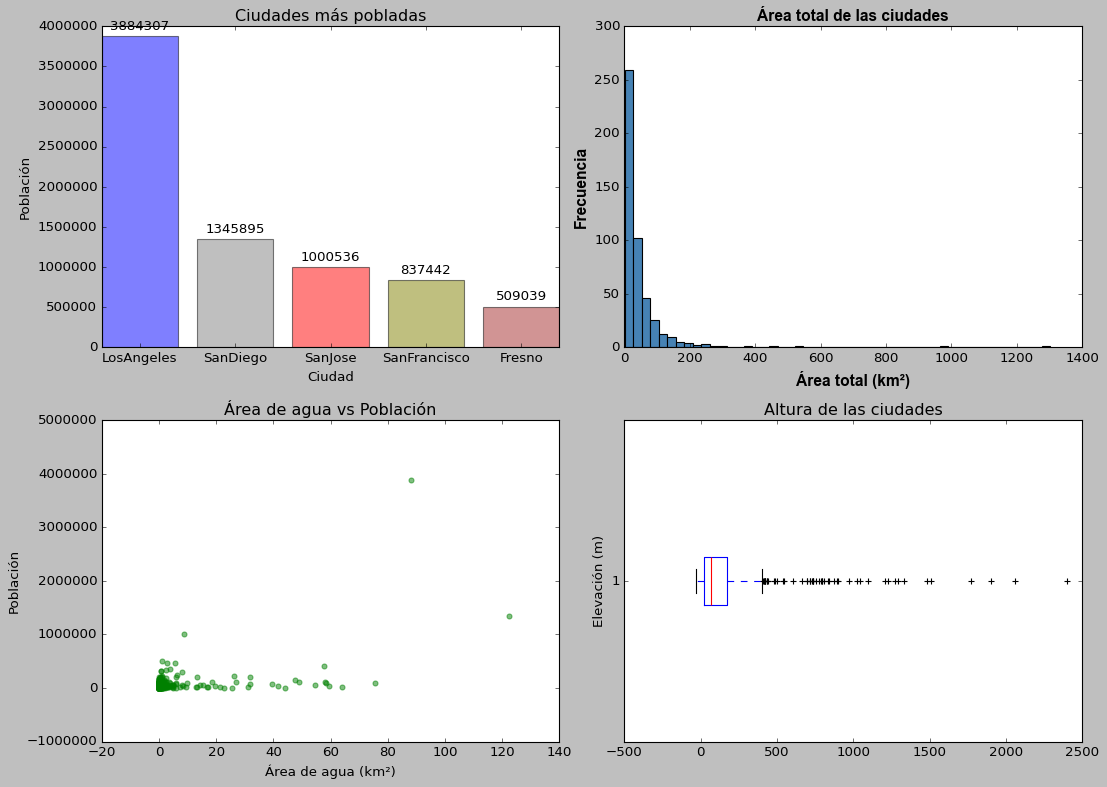

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Barras ---
ax = axes[0, 0]
bars = ax.bar(top5["city"], top5["population_total"], color=colores, alpha=0.5)
ax.bar_label(bars, fmt="%d", label_type="edge", padding=3)
ax.set_title("Ciudades más pobladas")
ax.set_xlabel("Ciudad")
ax.set_ylabel("Población")

# --- Histograma ---
ax = axes[0, 1]
ax.hist(df["area_total_km2"], bins=50, color="steelblue")
ax.set_title("Área total de las ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax.set_xlabel("Área total (km²)", fontname="Arial", fontsize=14, fontweight="bold")
ax.set_ylabel("Frecuencia", fontname="Arial", fontsize=14, fontweight="bold")

# --- Scatter ---
ax = axes[1, 0]
ax.scatter(df["area_water_km2"], df["population_total"], alpha=0.5, color="green")
ax.set_title("Área de agua vs Población")
ax.set_xlabel("Área de agua (km²)")
ax.set_ylabel("Población")

# --- Boxplot ---
ax = axes[1, 1]
ax.boxplot(df["elevation_m"].dropna(), vert=False, whis=1.5)
ax.set_title("Altura de las ciudades")
ax.set_ylabel("Elevación (m)")

plt.tight_layout()
plt.show()


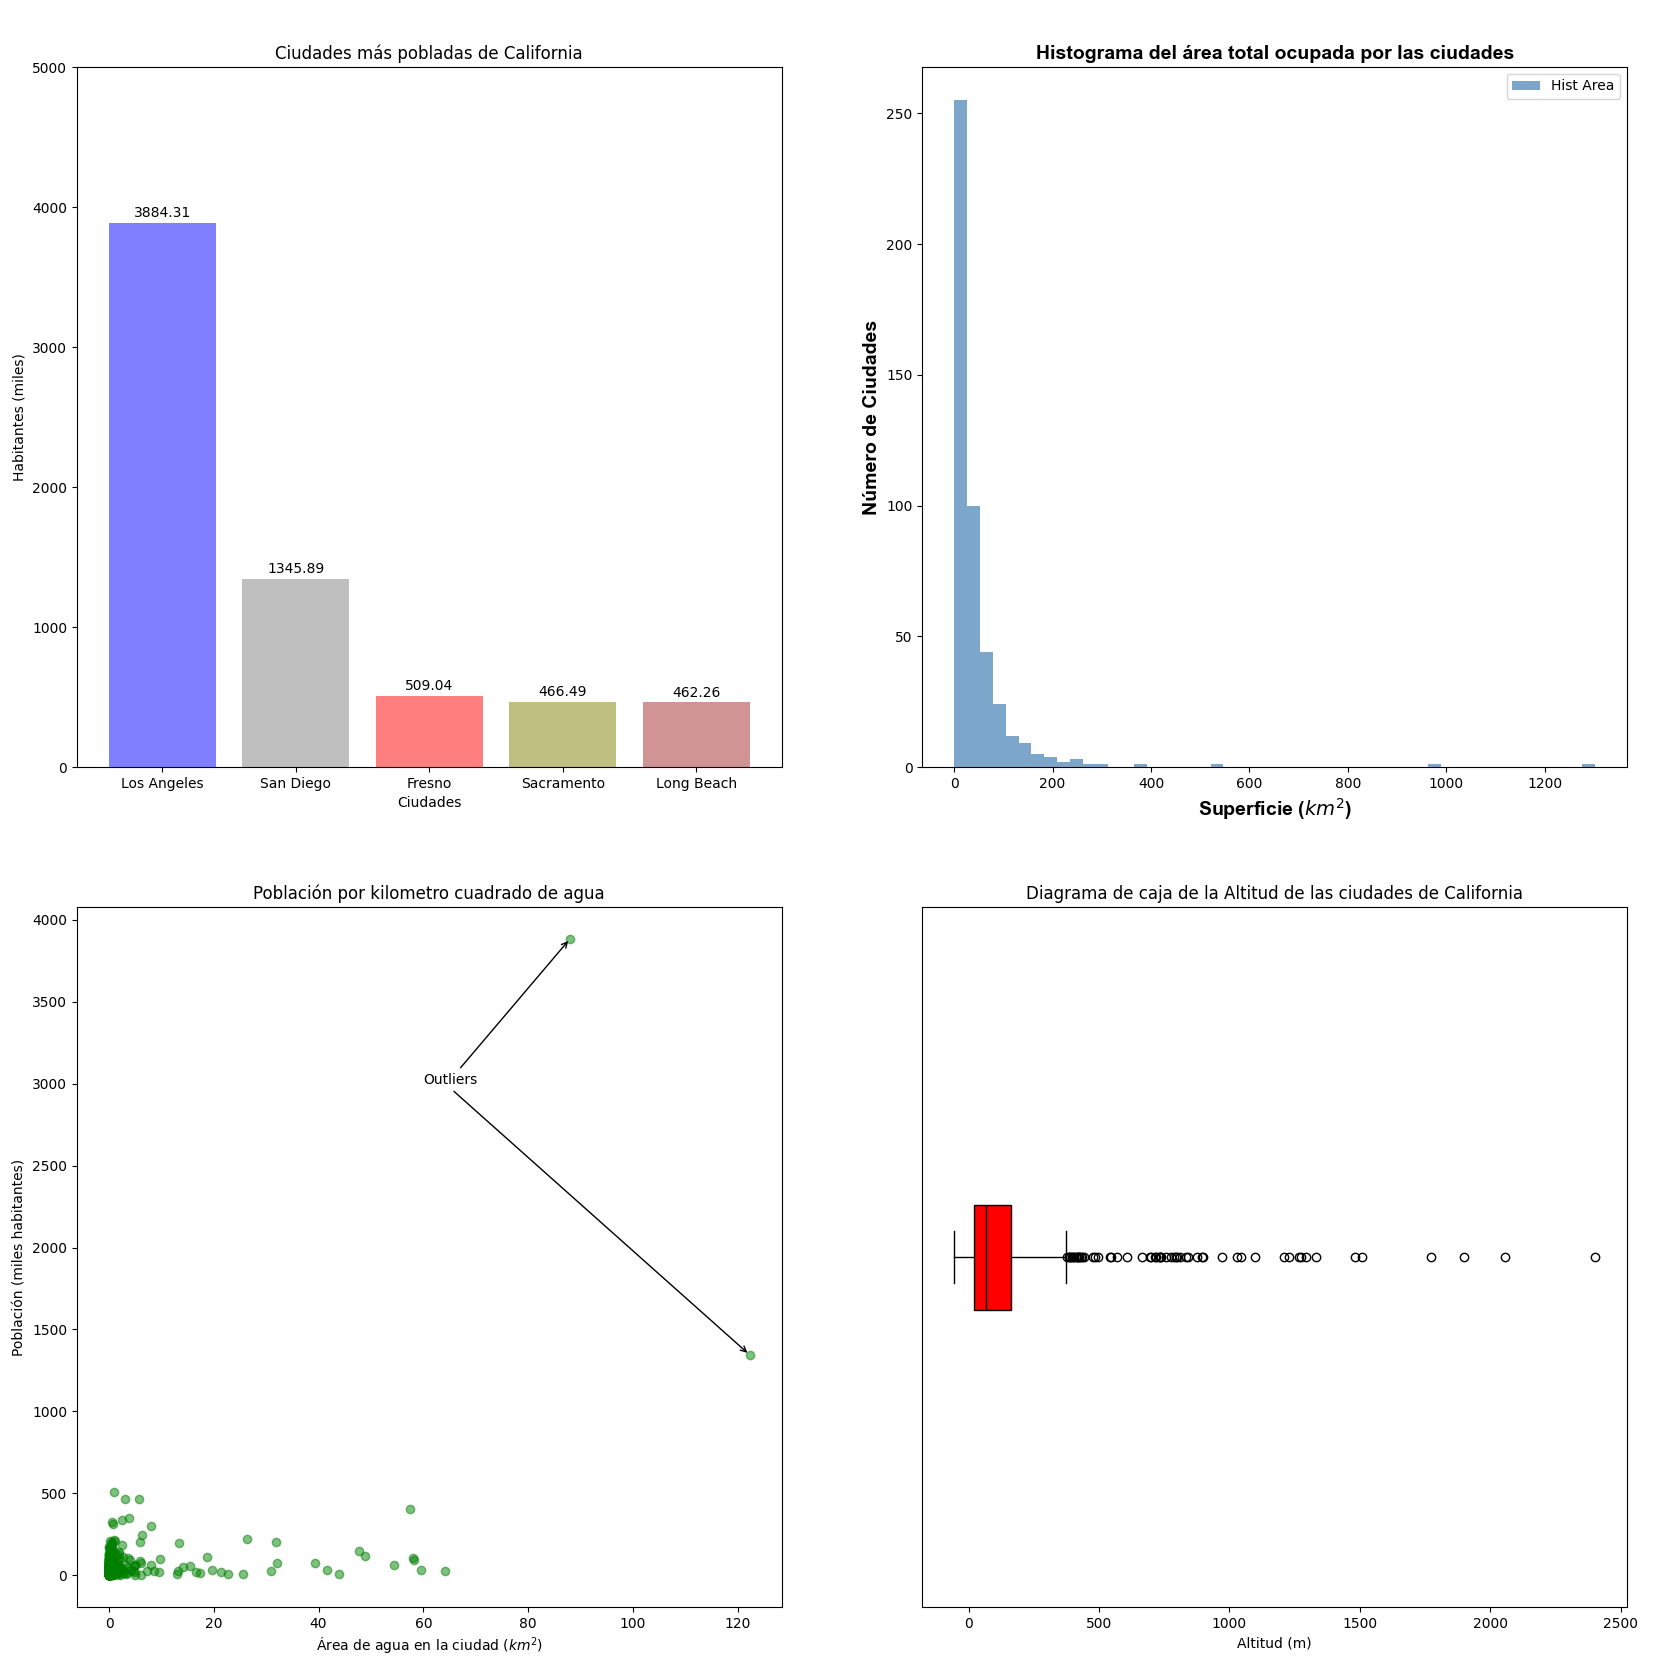

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [9]:
fig.savefig("practica_obligatoria.png", dpi=150, bbox_inches="tight")
